# **프로젝트: 네이버 영화리뷰 감성분석 도전하기**

In [1]:
import torch.nn.functional as F
import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from gensim.models import KeyedVectors
from gensim.models.keyedvectors import Word2VecKeyedVectors
import os
import numpy as np

In [2]:
# !wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
# !wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
# !mv ratings_*.txt ~/work/sentiment_classification/data

In [3]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/home/jovyan/work/20260410_rnn/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-04-12 15:16:14--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.134, 13.200.41.136, 13.200.41.135, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.134|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-12 15:16:15 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-k

In [4]:
# !pip install gensim==4.3.2

In [5]:
# 의존성 연결을 위해 다운그레이드를 진행합니다.
# !pip install scipy==1.12.0 numpy==1.26.3

In [6]:
import pandas
import konlpy
import gensim

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.3.0
0.6.0
4.3.2


## 1. 데이터 준비와 확인

In [7]:
import pandas as pd
import os

# 데이터를 읽어봅시다.
train_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## 2. 데이터로더 구성

 - imdb dataset : imdb.data_loader() 메서드를 호출하면 숫자 인덱스로 변환된 텍스트와 word_to_index 딕셔너리까지 제공
 - nsmc dataset : 가공되지 않은 텍스트 파일로 이루어짐. 이것을 읽어서 imdb.data_loader() 와 동일하게 동작하는 자신만의 data_loader를 만들어보자

## **data_loader**

- 데이터의 중복 제거
- NaN 결측치 제거
- 한국어 토크나이저로 토큰화
- 불용어(stopwords)제거
- 사전 word_to_index구성
- 텍스트 스트링을 사전 인덱스 스트링으로 변환
- X_train, y_train, X_test, y_test, word_to_index 리턴

In [8]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    # vocab 만들기
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    # encoding
    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [9]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [10]:
print(index_to_word[5]) 

'''
{3: '',
 4: '.',
 5: '영화',
 6: '다',
 7: '고',
 8: '하',
 9: '을', ...
'''

영화


"\n{3: '',\n 4: '.',\n 5: '영화',\n 6: '다',\n 7: '고',\n 8: '하',\n 9: '을', ...\n"

In [11]:
word_to_index["<PAD>"] = 0
word_to_index["<BOS>"] = 1
word_to_index["<UNK>"] = 2  # unknown
word_to_index["<UNUSED>"] = 3

In [12]:
# index_to_word

In [13]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

### **3. 모델 구성을 위한 데이터 분석 및 가공**

- 데이터셋 내 문장 길이 분포
- 적절한 최대 문장 길이 지정
- torch.nn.utils.rnn.pad_sequence 을 활용한 패딩 추가

## **Tokenization -> Encoding - >Padding -> Ebedding**

In [14]:
total_data_text = list(X_train) + list(X_test)

num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)
print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))


max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print('pad_sequences maxlen : ', maxlen)

문장길이 평균 :  15.971029850669861
문장길이 최대 :  116
문장길이 표준편차 :  12.844117035625121
pad_sequences maxlen :  41


In [15]:
# batch_first : 배치 차원을 앞에 둘지 말지 결정하는 옵션,True = (batch, seq_len),
# padding_value : 어떤 값을 채울지 결정
x_train_padded = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in X_train], batch_first=True, padding_value=0)
x_test_padded  = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in X_test], batch_first=True, padding_value=0)

In [16]:
# raw_inputs = [torch.tensor(sentence, dtype=torch.long) for sentence in raw_inputs]
# raw_inputs = torch.nn.utils.rnn.pad_sequence(raw_inputs, batch_first=True, padding_value=word_to_index['<PAD>'])

In [17]:
x_train_padded.shape, x_test_padded.shape

(torch.Size([146182, 116]), torch.Size([49157, 105]))

### **4. 모델 구성 및 validation set구성**

#### **1. RNN Model**

In [18]:
class RNNmodel(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(RNNmodel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.lstm = nn.LSTM(word_vector_dim, 8 , batch_first=True)
        self.fc1 = nn.Linear(8,8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x= self.embedding(x)
        lst_out, (h_n, c_n) =self.lstm(x)
        x = h_n[-1]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


### **2. 1D CNN**

In [19]:
class CNN_1D_model(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(CNN_1D_model, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=7)
        self.conv2 = nn.Conv1d(16, 16, kernel_size=7)
        self.pool = nn.MaxPool1d(5)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        # embedding 통과하면 (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)
        # permute 통과후 (batch, embed_dim, seq_len) 로 변경

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.global_max_pooling(x)

        # 텐서를 펴서(flatten) full connected layer에 넣기위한 작업
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

### **3. GlobalMaxPooling1d layer 사용**

- 전체 문장 중에서 단 하나의 가장 중요한 단어만 피처로 추출하여 그것을 문장의 긍정/부정을 평가하는 방식

In [20]:
class GMP_model(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(GMP_model, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(word_vector_dim, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8,1)
        self.sigmoid = nn.Sigmoid()


    def forward(self,x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

In [21]:
# validation set 10000건 분리
x_val = x_train_padded[:10000,:]
y_val = y_train[:10000]

# validation set을 제외한 나머지 15000건
partial_x_train = x_train_padded[10000:]
partial_y_train = y_train[10000:]

partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
partial_y_train_tensor = torch.tensor(partial_y_train, dtype=torch.float)

x_val_tensor = torch.tensor(x_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float)

train_dataset = TensorDataset(partial_x_train_tensor, partial_y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)


### test data ###
x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float)

test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

/tmp/ipykernel_12432/3743836521.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  partial_x_train_tensor = torch.tensor(partial_x_train, dtype=torch.long)
/tmp/ipykernel_12432/3743836521.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_val_tensor = torch.tensor(x_val, dtype=torch.long)
/tmp/ipykernel_12432/3743836521.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)


In [22]:
train_loader

In [23]:
vocab_size = len(word_to_index)
word_vector_dim = 200

rnn_model=RNNmodel(vocab_size, word_vector_dim)
cnn_1d_model=CNN_1D_model(vocab_size, word_vector_dim)
gmp_model=GMP_model(vocab_size, word_vector_dim)


### **5. 모델 훈련 개시**

In [24]:
import random

random.seed(20260412)

loss_fn = torch.nn.BCELoss()
bcelogit_loss_fn = torch.nn.BCEWithLogitsLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

loss_fn = loss_fn.to(device)
bcelogit_loss_fn=bcelogit_loss_fn.to(device)
EPOCH = 20

Using device: cuda


In [25]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [26]:
import torch

def train(model, EPOCH, loss_fn, optimizer, train_loader, val_loader):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = model.to(device)

    for epoch in range(EPOCH):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            predicted = (probs.squeeze() > 0.5).float()

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        # 🔹 validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                # 🔥 validation도 GPU로
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), labels)

                val_loss += loss.item()

                probs = torch.sigmoid(outputs)
                predicted = (probs.squeeze() > 0.5).float()

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)

        print(f"Epoch {epoch+1}/{EPOCH} - "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} - "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [27]:
def test(model, test_loader):
    model = model.to(device)
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = loss_fn(outputs.squeeze(), labels)
            test_loss += loss.item()

            probs = torch.sigmoid(outputs)
            predicted = (probs.squeeze() > 0.5).float()

            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = test_correct / test_total

    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

    return avg_loss, accuracy

In [28]:
rnn_train_losses, rnn_val_losses, rnn_train_accs, rnn_val_accs = train(rnn_model, EPOCH, loss_fn,torch.optim.Adam(rnn_model.parameters(), lr=0.001), train_loader, val_loader)

Using device: cuda
Epoch 1/20 - Train Loss: 0.6933, Train Acc: 0.4984 - Val Loss: 0.6931, Val Acc: 0.4973
Epoch 2/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 3/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 4/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 5/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 6/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6931, Val Acc: 0.4973
Epoch 7/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 8/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6931, Val Acc: 0.4973
Epoch 9/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 10/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6932, Val Acc: 0.4973
Epoch 11/20 - Train Loss: 0.6932, Train Acc: 0.4984 - Val Loss: 0.6931, Val Acc: 0.4973
Epoch 12/20 - Train Lo

In [29]:
cnn_1d_train_losses, cnn_1d_val_losses, cnn_1d_train_accs, cnn_1d_val_accs = train(cnn_1d_model, EPOCH, loss_fn, torch.optim.Adam(cnn_1d_model.parameters(), lr=0.001), train_loader, val_loader)

Using device: cuda
Epoch 1/20 - Train Loss: 0.4424, Train Acc: 0.4984 - Val Loss: 0.3615, Val Acc: 0.4973
Epoch 2/20 - Train Loss: 0.3274, Train Acc: 0.4984 - Val Loss: 0.3381, Val Acc: 0.4973
Epoch 3/20 - Train Loss: 0.2865, Train Acc: 0.4984 - Val Loss: 0.3330, Val Acc: 0.4973
Epoch 4/20 - Train Loss: 0.2535, Train Acc: 0.4984 - Val Loss: 0.3445, Val Acc: 0.4973
Epoch 5/20 - Train Loss: 0.2229, Train Acc: 0.4984 - Val Loss: 0.3742, Val Acc: 0.4973
Epoch 6/20 - Train Loss: 0.1935, Train Acc: 0.4984 - Val Loss: 0.3871, Val Acc: 0.4973
Epoch 7/20 - Train Loss: 0.1642, Train Acc: 0.4985 - Val Loss: 0.4197, Val Acc: 0.4973
Epoch 8/20 - Train Loss: 0.1395, Train Acc: 0.4996 - Val Loss: 0.4633, Val Acc: 0.4976
Epoch 9/20 - Train Loss: 0.1177, Train Acc: 0.5039 - Val Loss: 0.5338, Val Acc: 0.5020
Epoch 10/20 - Train Loss: 0.1024, Train Acc: 0.5118 - Val Loss: 0.5854, Val Acc: 0.5076
Epoch 11/20 - Train Loss: 0.0890, Train Acc: 0.5230 - Val Loss: 0.6898, Val Acc: 0.5279
Epoch 12/20 - Train Lo

In [30]:
gmp_train_losses, gmp_val_losses, gmp_train_accs, gmp_val_accs = train(gmp_model, EPOCH, loss_fn, torch.optim.Adam(gmp_model.parameters(), lr=0.001), train_loader, val_loader)

Using device: cuda
Epoch 1/20 - Train Loss: 0.5295, Train Acc: 0.4984 - Val Loss: 0.4174, Val Acc: 0.4973
Epoch 2/20 - Train Loss: 0.3860, Train Acc: 0.4984 - Val Loss: 0.3778, Val Acc: 0.4973
Epoch 3/20 - Train Loss: 0.3432, Train Acc: 0.4984 - Val Loss: 0.3627, Val Acc: 0.4973
Epoch 4/20 - Train Loss: 0.3154, Train Acc: 0.4984 - Val Loss: 0.3541, Val Acc: 0.4973
Epoch 5/20 - Train Loss: 0.2923, Train Acc: 0.4984 - Val Loss: 0.3580, Val Acc: 0.4973
Epoch 6/20 - Train Loss: 0.2733, Train Acc: 0.4984 - Val Loss: 0.3581, Val Acc: 0.4973
Epoch 7/20 - Train Loss: 0.2540, Train Acc: 0.4984 - Val Loss: 0.3639, Val Acc: 0.4973
Epoch 8/20 - Train Loss: 0.2374, Train Acc: 0.4984 - Val Loss: 0.3739, Val Acc: 0.4973
Epoch 9/20 - Train Loss: 0.2209, Train Acc: 0.4984 - Val Loss: 0.3809, Val Acc: 0.4973
Epoch 10/20 - Train Loss: 0.2044, Train Acc: 0.4984 - Val Loss: 0.4066, Val Acc: 0.4973
Epoch 11/20 - Train Loss: 0.1891, Train Acc: 0.4984 - Val Loss: 0.4126, Val Acc: 0.4973
Epoch 12/20 - Train Lo

In [31]:
rnn_test_loss, rnn_test_acc = test(rnn_model, test_loader)
cnn_1d_test_loss, cnn_1d_test_acc = test(cnn_1d_model, test_loader)
gmp_test_loss, gmp_test_acc = test(gmp_model, test_loader)

print(f'Loss = RNN :{ rnn_test_loss}, 1D CNN : {cnn_1d_test_loss}, GlobalMaxPooling : {gmp_test_loss}')
print(f'ACC = RNN :{ rnn_test_acc}, 1D CNN : {cnn_1d_test_acc}, GlobalMaxPooling : {gmp_test_acc}')

Test Loss: 0.4150, Test Accuracy: 0.5027
Test Loss: 1.5512, Test Accuracy: 0.6158
Test Loss: 0.6974, Test Accuracy: 0.5097
Loss = RNN :0.41497607200176684, 1D CNN : 1.5511715587083394, GlobalMaxPooling : 0.697430648122515
ACC = RNN :0.5026954452061762, 1D CNN : 0.615822771934821, GlobalMaxPooling : 0.5096730882682019


- BCELogitLoss로 변경 ,lr 0.01로 변경

In [ ]:
# rnn2_train_losses, rnn2_val_losses, rnn2_train_accs, rnn2_val_accs = train(rnn_model, EPOCH,bcelogit_loss_fn, torch.optim.Adam(rnn_model.parameters(), lr=0.01), train_loader, val_loader)

In [ ]:
# cnn2_1d_train_losses, cnn2_1d_val_losses, cnn2_1d_train_accs, cnn2_1d_val_accs = train(cnn_1d_model, EPOCH,bcelogit_loss_fn, torch.optim.Adam(cnn_1d_model.parameters(), lr=0.01), train_loader, val_loader)

In [ ]:
# gmp2_train_losses, gmp2_val_losses, gmp2_train_accs, gmp2_val_accs = train(gmp_model, 30, bcelogit_loss_fn, torch.optim.Adam(gmp_model.parameters(), lr=0.001), train_loader, val_loader)

### **6. Looss, Accuracy 그래프 시각화**

In [33]:
def plot_training_history(train_losses, val_losses, train_accs, val_accs, title="Training Results"):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))
    plt.suptitle(title, fontsize=16)

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, color='blue', marker='o', label='Train Loss')
    plt.plot(epochs, val_losses, color='red', marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()
    plt.ylim([0,0.8])
    plt.xticks(np.arange(1, len(train_losses)+2, 4))
    plt.grid()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, color='blue', marker='o', label='Train Acc')
    plt.plot(epochs, val_accs, color='red', marker='o', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.grid()
    plt.ylim([0,1])
    plt.xticks(np.arange(1, len(train_losses)+2, 4))

    plt.tight_layout()

    
    plt.show()

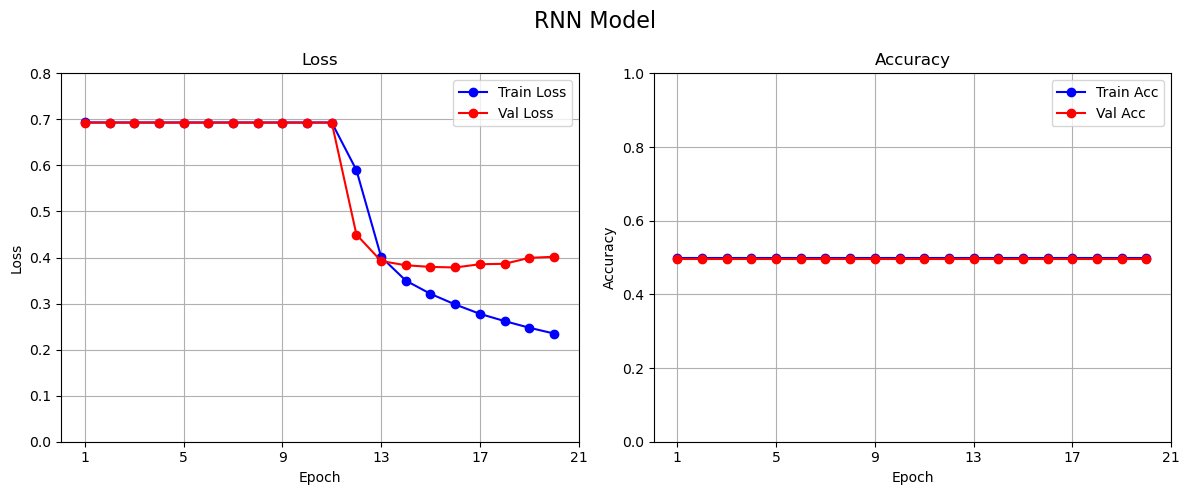

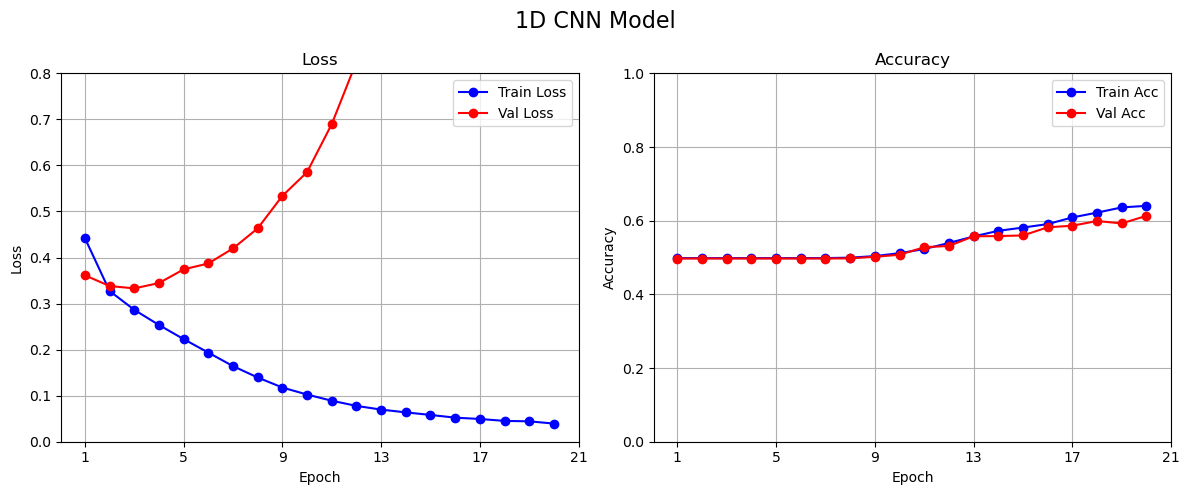

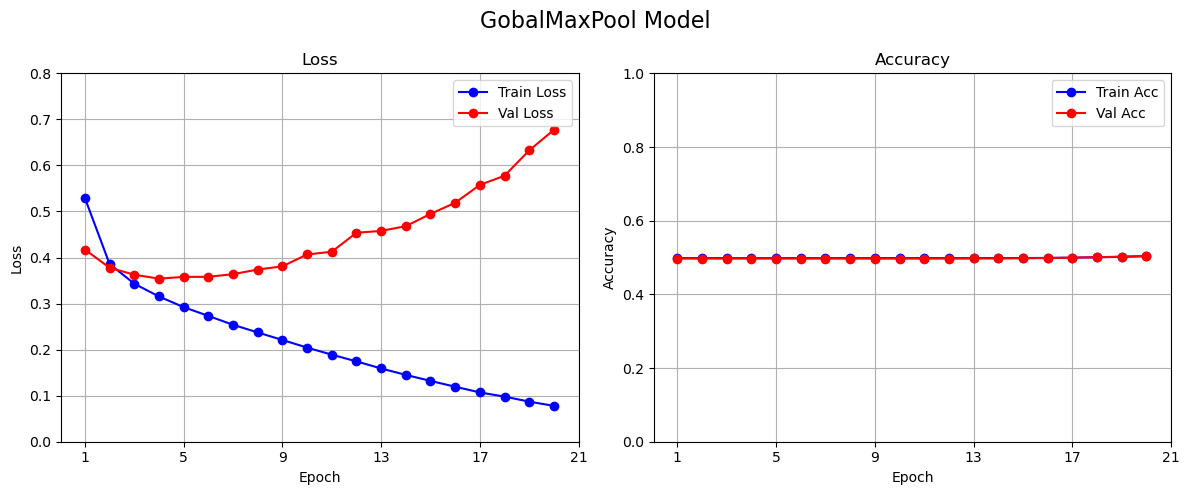

In [34]:
plot_training_history(
    rnn_train_losses,
    rnn_val_losses,
    rnn_train_accs,
    rnn_val_accs,
    title="RNN Model"
)

plot_training_history(
    cnn_1d_train_losses,
    cnn_1d_val_losses,
    cnn_1d_train_accs,
    cnn_1d_val_accs,
    title="1D CNN Model"
)

plot_training_history(
    gmp_train_losses,
    gmp_val_losses,
    gmp_train_accs,
    gmp_val_accs,
    title="GobalMaxPool Model"
)

### **7. 학습된 Embedding 레이어 분석**

In [35]:
rnn_embedding_weights = rnn_model.embedding.weight.data
cnn_1d_embedding_weights = cnn_1d_model.embedding.weight.data
gmp_embedding_weights = gmp_model.embedding.weight.data

In [36]:
def get_similar_words(word, embedding_weights, word_to_index, index_to_word, top_k=5):
    if word not in word_to_index:
        return f"{word} not in vocab"

    idx = word_to_index[word]
    target_vec = embedding_weights[idx]

    similarities = F.cosine_similarity(
        target_vec.unsqueeze(0),
        embedding_weights
    )

    top_indices = similarities.topk(top_k + 1).indices.tolist()

    return [index_to_word[i] for i in top_indices if i != idx][:top_k]

In [37]:
word = "영화"

print("RNN:", get_similar_words(word, rnn_embedding_weights, word_to_index, index_to_word))
print("CNN:", get_similar_words(word, cnn_1d_embedding_weights, word_to_index, index_to_word))
print("GMP:", get_similar_words(word, gmp_embedding_weights, word_to_index, index_to_word))

RNN: ['죄악', '아프리카', '스머프', '먹여', '좀비']
CNN: ['꿀꿀', '괴기', '성', '영어', '대결']
GMP: ['프로그램', '스킬', '쭉', 'REC', '아따']


- RNN -> 문맥중심
- CNN -> 패턴중심
- GMP -> 특징중심

In [38]:
# import matplotlib.font_manager as fm
# font_path = './NanumGothic.ttf'
# fm.fontManager.addfont(font_path)
# plt.rcParams['font.family'] = 'NanumGothic'
# print(plt.rcParams['font.family'])

In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_imdb(embedding_weights, X_data, y_data, title="t-SNE (IMDB)", num_points=1000):

    # 🔥 embedding CPU로 이동 (중요)
    embedding_weights = embedding_weights.cpu()

    sentence_vectors = []

    for seq in X_data[:num_points]:
        seq_tensor = torch.tensor(seq)

        vecs = embedding_weights[seq_tensor]  # (seq_len, embed_dim)
        sentence_vec = vecs.mean(dim=0)

        # 🔥 핵심 수정
        sentence_vectors.append(sentence_vec.detach().cpu().numpy())

    sentence_vectors = np.array(sentence_vectors)
    labels = y_data[:num_points]

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(sentence_vectors)

    # 색상 (label 기준)
    colors = ['red' if l == 1 else 'blue' for l in labels]

    plt.figure(figsize=(5, 5))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, alpha=0.6)

    plt.title(title)
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")

    # 범례
    plt.scatter([], [], c='red', label='Positive')
    plt.scatter([], [], c='blue', label='Negative')
    plt.legend()

    plt.show()

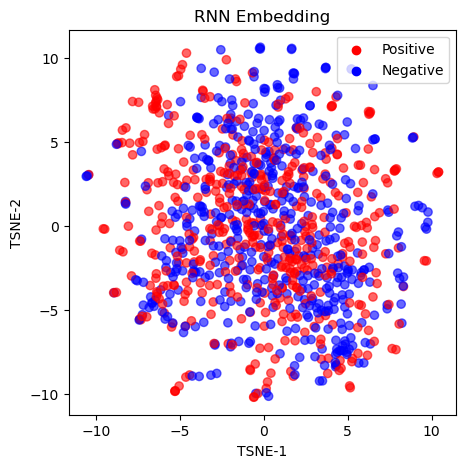

In [51]:
plot_tsne_imdb(rnn_embedding_weights,X_train,y_train,"RNN Embedding")

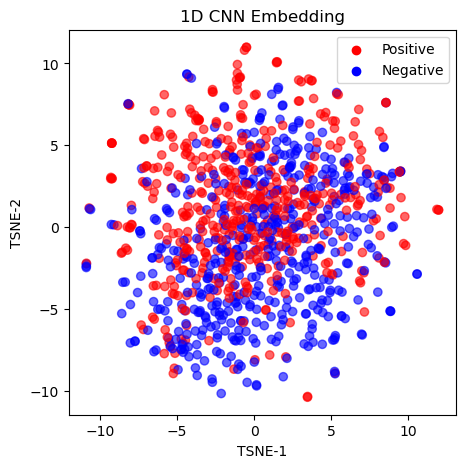

In [52]:
plot_tsne_imdb(cnn_1d_embedding_weights, X_train, y_train, "1D CNN Embedding")

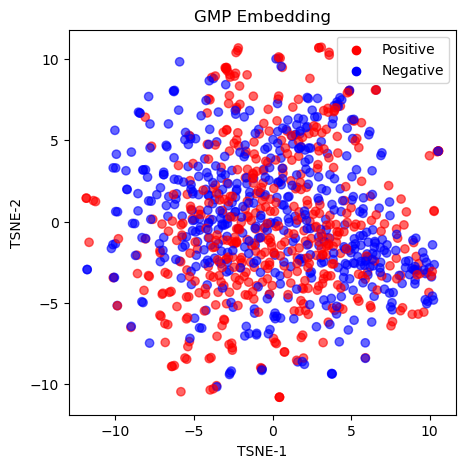

In [53]:
plot_tsne_imdb(gmp_embedding_weights, X_train, y_train, "GMP Embedding")

### **8. 한국어 Word2Vec 임베딩 활용하여 성능 개선**

- 한국어 Word2Vec은 /data 폴더 안에 있는 word2vec_ko.model을 활용하세요.

In [ ]:
'''
# 예시 코드
from gensim.models.keyedvectors import Word2VecKeyedVectors
word_vectors = Word2VecKeyedVectors.load(word2vec_file_path)
vector = word_vectors.wv[‘끝’]
'''

In [44]:
from gensim.models import Word2Vec

In [45]:
w2v_model = Word2Vec.load("/home/jovyan/data/word2vec_ko.model")

In [46]:
# 벡터 가져오기
w2v_vectors = w2v_model.wv

In [47]:
w2v_vectors.most_similar("영화", topn=5)

[('드라마', 0.8418774008750916),
 ('뮤지컬', 0.7775140404701233),
 ('코미디', 0.7489107251167297),
 ('다큐멘터리', 0.7401294708251953),
 ('헐리우드', 0.7397844195365906)]

In [48]:
def get_similar_words(word, embedding_weights, word_to_index, index_to_word, top_k=5):
    import torch.nn.functional as F

    if word not in word_to_index:
        return f"{word} not in vocab"

    idx = word_to_index[word]
    target_vec = embedding_weights[idx]

    similarities = F.cosine_similarity(
        target_vec.unsqueeze(0),
        embedding_weights
    )

    top_indices = similarities.topk(top_k + 1).indices.tolist()

    return [index_to_word[i] for i in top_indices if i != idx][:top_k]

In [49]:
word = "영화"

print("Word2Vec:", w2v_model.wv.most_similar(word))
print("RNN:", get_similar_words(word, rnn_embedding_weights, word_to_index, index_to_word))
print("CNN:", get_similar_words(word, cnn_1d_embedding_weights, word_to_index, index_to_word))
print("GMP:", get_similar_words(word, gmp_embedding_weights, word_to_index, index_to_word))

Word2Vec: [('드라마', 0.8418774008750916), ('뮤지컬', 0.7775140404701233), ('코미디', 0.7489107251167297), ('다큐멘터리', 0.7401294708251953), ('헐리우드', 0.7397844195365906), ('애니메이션', 0.7170552015304565), ('독립영화', 0.7113528251647949), ('로맨틱', 0.7107657194137573), ('장편', 0.7101576924324036), ('극영화', 0.7045413255691528)]
RNN: ['죄악', '아프리카', '스머프', '먹여', '좀비']
CNN: ['꿀꿀', '괴기', '성', '영어', '대결']
GMP: ['프로그램', '스킬', '쭉', 'REC', '아따']


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_word2vec_imdb(w2v_model, X_data, y_data, index_to_word, title="Word2Vec t-SNE", num_points=1000):

    sentence_vectors = []

    for seq in X_data[:num_points]:
        words = [index_to_word.get(idx, None) for idx in seq]

        vecs = []
        for word in words:
            if word and word in w2v_model.wv:
                vecs.append(w2v_model.wv[word])

        # 👉 단어 하나도 없을 경우 대비
        if len(vecs) == 0:
            vecs.append(np.zeros(w2v_model.vector_size))

        sentence_vec = np.mean(vecs, axis=0)
        sentence_vectors.append(sentence_vec)

    sentence_vectors = np.array(sentence_vectors)
    labels = y_data[:num_points]

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    reduced = tsne.fit_transform(sentence_vectors)

    # 색상 (label 기준)
    colors = ['red' if l == 1 else 'blue' for l in labels]

    plt.figure(figsize=(5, 5))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, alpha=0.6)

    plt.title(title)
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")

    # 범례
    plt.scatter([], [], c='red', label='Positive')
    plt.scatter([], [], c='blue', label='Negative')
    plt.legend()

    plt.show()

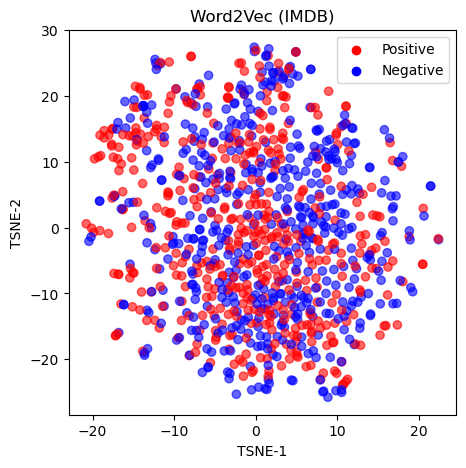

In [57]:
plot_tsne_word2vec_imdb(
    w2v_model,
    X_train,
    y_train,
    index_to_word,
    title="Word2Vec (IMDB)"
)

### 회고

- RNN 모델은 BCELoss(), BCELogitLoss(), lr= 0.01, 0.001 등등 다양하게 하이퍼파라미터를 바꿔도 val_accu가 일정하게 나왔다. 어디를 고쳐야할지 잘 모르겠다
- word2vec_ko.model은 '영화' 넣으면 드라마, 뮤지컬, 코미디..이런 output이 나오는데, 내가 돌린 rnn, 1d cnn, globalmaxpooling 모델은 영화랑 전혀 관련 없는 단어들이 나온다
- 3번 루브릭 실패 : 85% 도달할 수 없다..
- t-SNE로 Embedding 분포를 시각적으로 확인해서 서로 잘 분리되어있는지 확인하는 방법이 있다. 비교를 위해 Word2Vec도 같이 분포